# Random Number Generation and Probability Distributions

From-scratch NumPy experiments on generating random numbers and exploring the distributions they produce — uniform sampling, approximating a Gaussian via the central-limit approach, and the resulting summary statistics.

### Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Part 1

In [2]:
np.random.seed(2026)
random_numbers = np.random.rand(50000)
print("Used ", 2026, " as the seed")
print("Used \"np.random.rand(50000)\" as the function")

Used  2026  as the seed
Used "np.random.rand(50000)" as the function


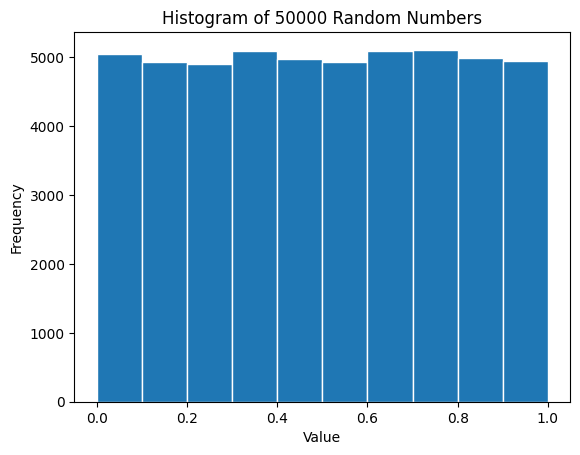

In [3]:
plt.hist(random_numbers, bins=10, range = (0,1), edgecolor = 'white')
plt.title('Histogram of 50000 Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

**ANALYSIS**

The histogram was expected to look like a uniform distribution because if the numbers are randomly generated, that means each number has the equivalent possibility to appear. Since the probability is all equal, it is likely to generate a uniform distribution. Since the sample size is 50,000, each bin count will be approximately 5,000 each. The histogram bin counts match the expectation as they show similar counts (5,000 each) for each bin.

Deviations from uniformity might occur due to sampling noise. Having the same probability does not mean it necessarily generates each one after another, so there can be slight deviations. However, as the sample size increases, the degrees of the deviations will get lower.

### Part 2

In [4]:
random_numbers_ = np.random.rand(12*50000)
np.array(random_numbers_)
random_numbers_ = random_numbers_.reshape(50000, 12)
random_numbers_normdist = np.zeros(50000)
for i in range(50000):
    random_numbers_normdist[i] = random_numbers_[i].sum()

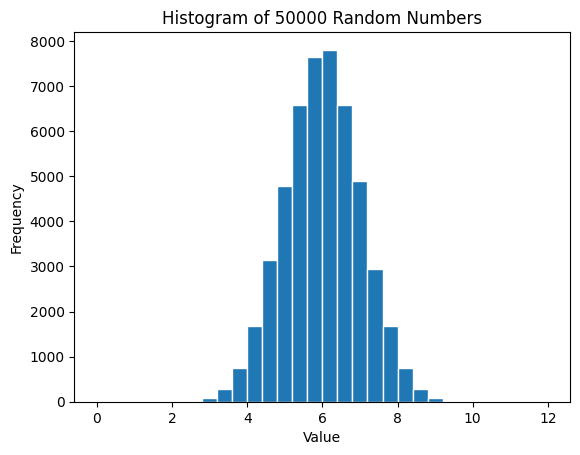

In [5]:
plt.hist(random_numbers_normdist, bins=30, range = (0,12), edgecolor = 'white')
plt.title('Histogram of 50000 Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [6]:
mean_normdist = np.sum(random_numbers_normdist) / 50000
std_normdist = np.sqrt(np.sum((random_numbers_normdist - mean_normdist)**2) / 50000)
print('Mean: ',mean_normdist)
print('Standard Deviation: ',std_normdist)

Mean:  5.998228115716766
Standard Deviation:  1.0034987838555864


**ANALYSIS**

The mean is ~5.998, and the standard deviation is ~1.003 of my generated values.

Based on the method I used, the theoretical mean should be 6 and the standard deviation should be 1. If the probability of each event's occurence (any random number from 0 to 1) is the same, the theoretical mean value of the sample will be 0.5. If 12 of these values are added up as 1 value, then the theoretical mean value of this sample set of 12 random numbers added will be 6. We can estimate the standard deviation by deriving it from the standard deviation of the uniform distribution, which is 1/12. Since 12 values are added up, we can add up their variance, which is 1. The standard deviation is the square root of the variance, therefore 1.

I would say my empirical results match the theoretical prediction. The actual values are extremely close to the theoretical ones, and if you round them up to the nearest hundredth, it is exactly the theoretical values.

### Part 3

#### Setup:

In [7]:
def generate_randvec_normalized(d): # d is the dimension of the vector
  randvec_zeromean = np.random.rand(d) - 0.5
  randvec_normalized = randvec_zeromean / np.sqrt(np.sum(randvec_zeromean**2))
  return randvec_normalized

#### PART 1:

In [8]:
def dotproduct(d): # d is dimension of the vector
  randvec1 = generate_randvec_normalized(d)
  randvec2 = generate_randvec_normalized(d)
  dotproduct = np.sum(randvec1*randvec2)
  return dotproduct

In [9]:
def dotproduct_list(d, n): # d is the dimension of the vector, n is the number of samples
  dotproduct_list = []
  for i in range(n):
    dotproduct_list.append(dotproduct(d))
  return dotproduct_list

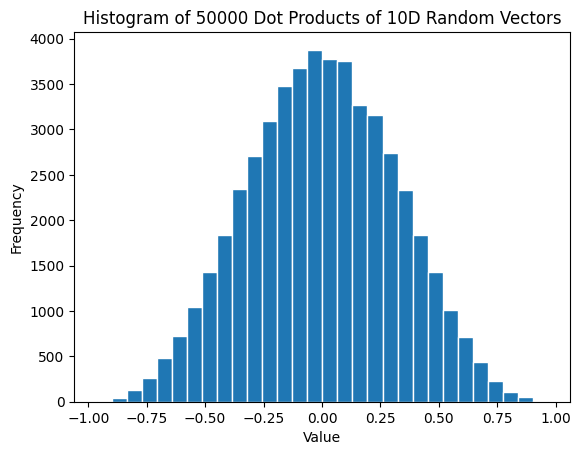

10-dimension
Mean:  0.0002738512226285419
Standard Deviation:  0.31542519111934003


In [10]:
dot = dotproduct_list(10,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 10D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('10-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

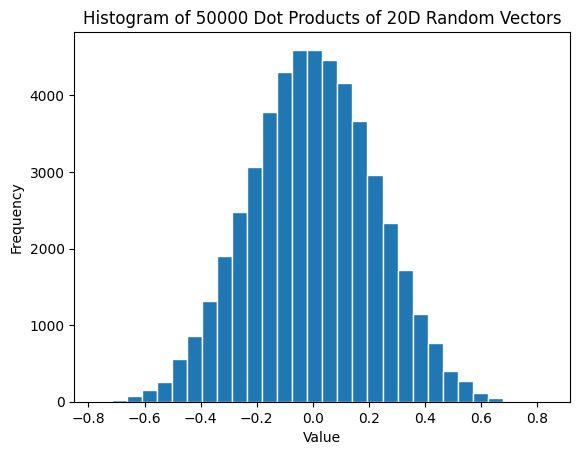

20-dimension
Mean:  0.0003426938376381029
Standard Deviation:  0.22309163794973866


In [11]:
dot = dotproduct_list(20,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 20D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('20-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

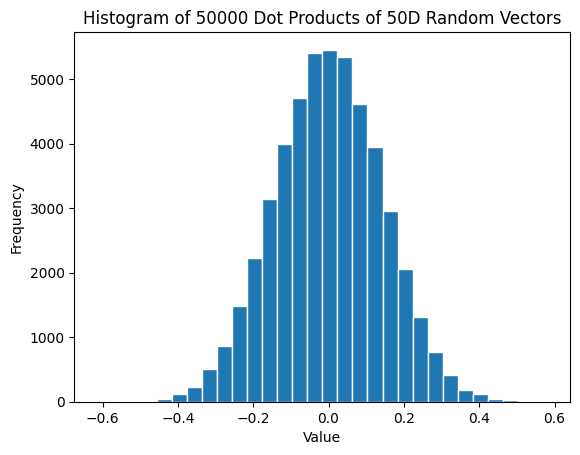

50-dimension
Mean:  -0.0001623063257355156
Standard Deviation:  0.14193887355915497


In [12]:
dot = dotproduct_list(50,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 50D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('50-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

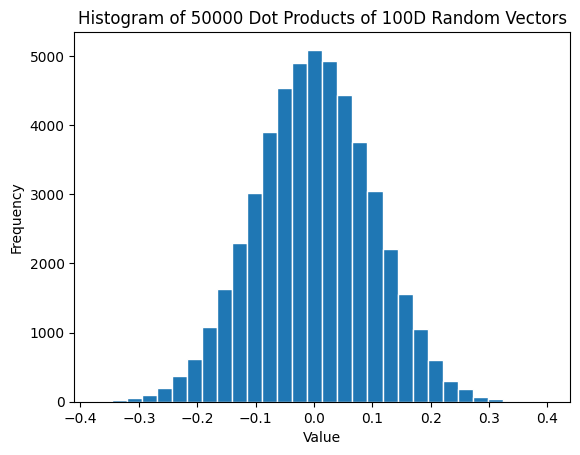

100-dimension
Mean:  7.923998217971205e-05
Standard Deviation:  0.09982186012065357


In [13]:
dot = dotproduct_list(100,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 100D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('100-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

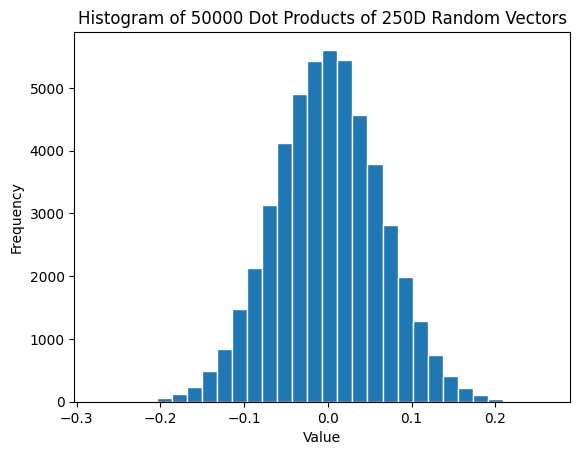

250-dimension
Mean:  4.577058889141951e-05
Standard Deviation:  0.0635445946175183


In [14]:
dot = dotproduct_list(250,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 250D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('250-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

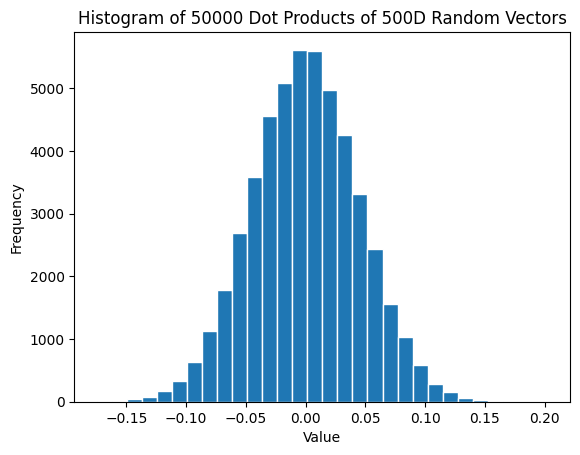

500-dimension
Mean:  -6.24606431064275e-05
Standard Deviation:  0.04457921031853825


In [15]:
dot = dotproduct_list(500,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 500D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('500-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

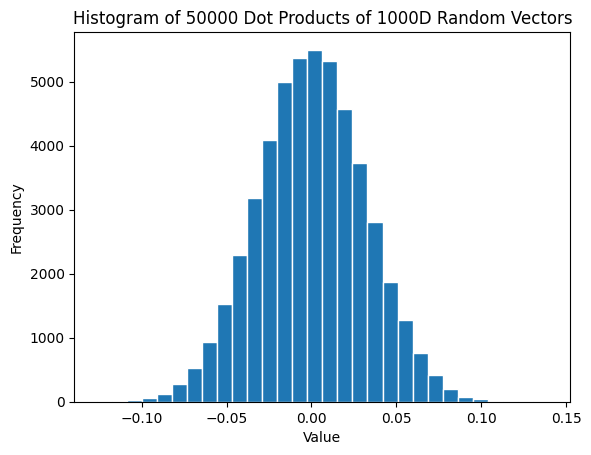

1000-dimension
Mean:  9.60877825385226e-05
Standard Deviation:  0.03167072404101109


In [16]:
dot = dotproduct_list(1000,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 1000D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('1000-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

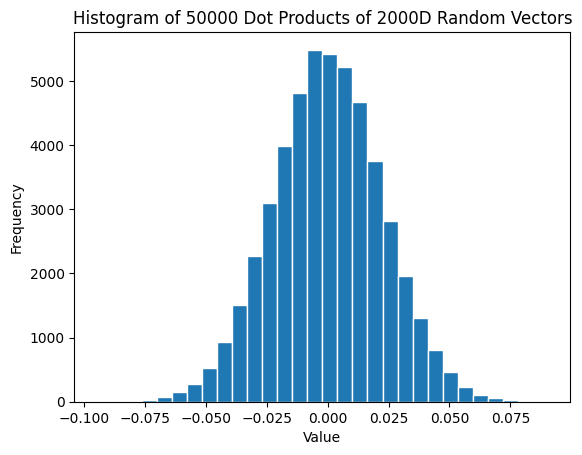

2000-dimension
Mean:  3.6364410390761126e-06
Standard Deviation:  0.022320142074007347


In [17]:
dot = dotproduct_list(2000,50000)

plt.hist(dot, bins=30, edgecolor = 'white')
plt.title('Histogram of 50000 Dot Products of 2000D Random Vectors')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

mean_dot = np.sum(dot) / 50000
std_dot = np.sqrt(np.sum((dot - mean_dot)**2) / 50000)
print('2000-dimension')
print('Mean: ',mean_dot)
print('Standard Deviation: ',std_dot)

**ANALYSIS**

Dot products represents the cosine value of the angle between the two normalized vectors.

***MEANs and STDs are reported in each cell.***
 You can notice that the histograms get thinner as the dimension increases; that is, the standard deviation gets smaller.

The theoretical mean value is 0 due to geometric arrangement of the vectors. The vectors are distributed uniformly on the unit sphere (because it is normalized vectors) of the vector space. If there is a pair of vectors with a dot product of x, there is an equal probability of a pair of vectors with a dot product of -x existing. Since this makes the distribution symmetric around the origin, the mean is likely to be 0.

#### PART 2: (HINT A)

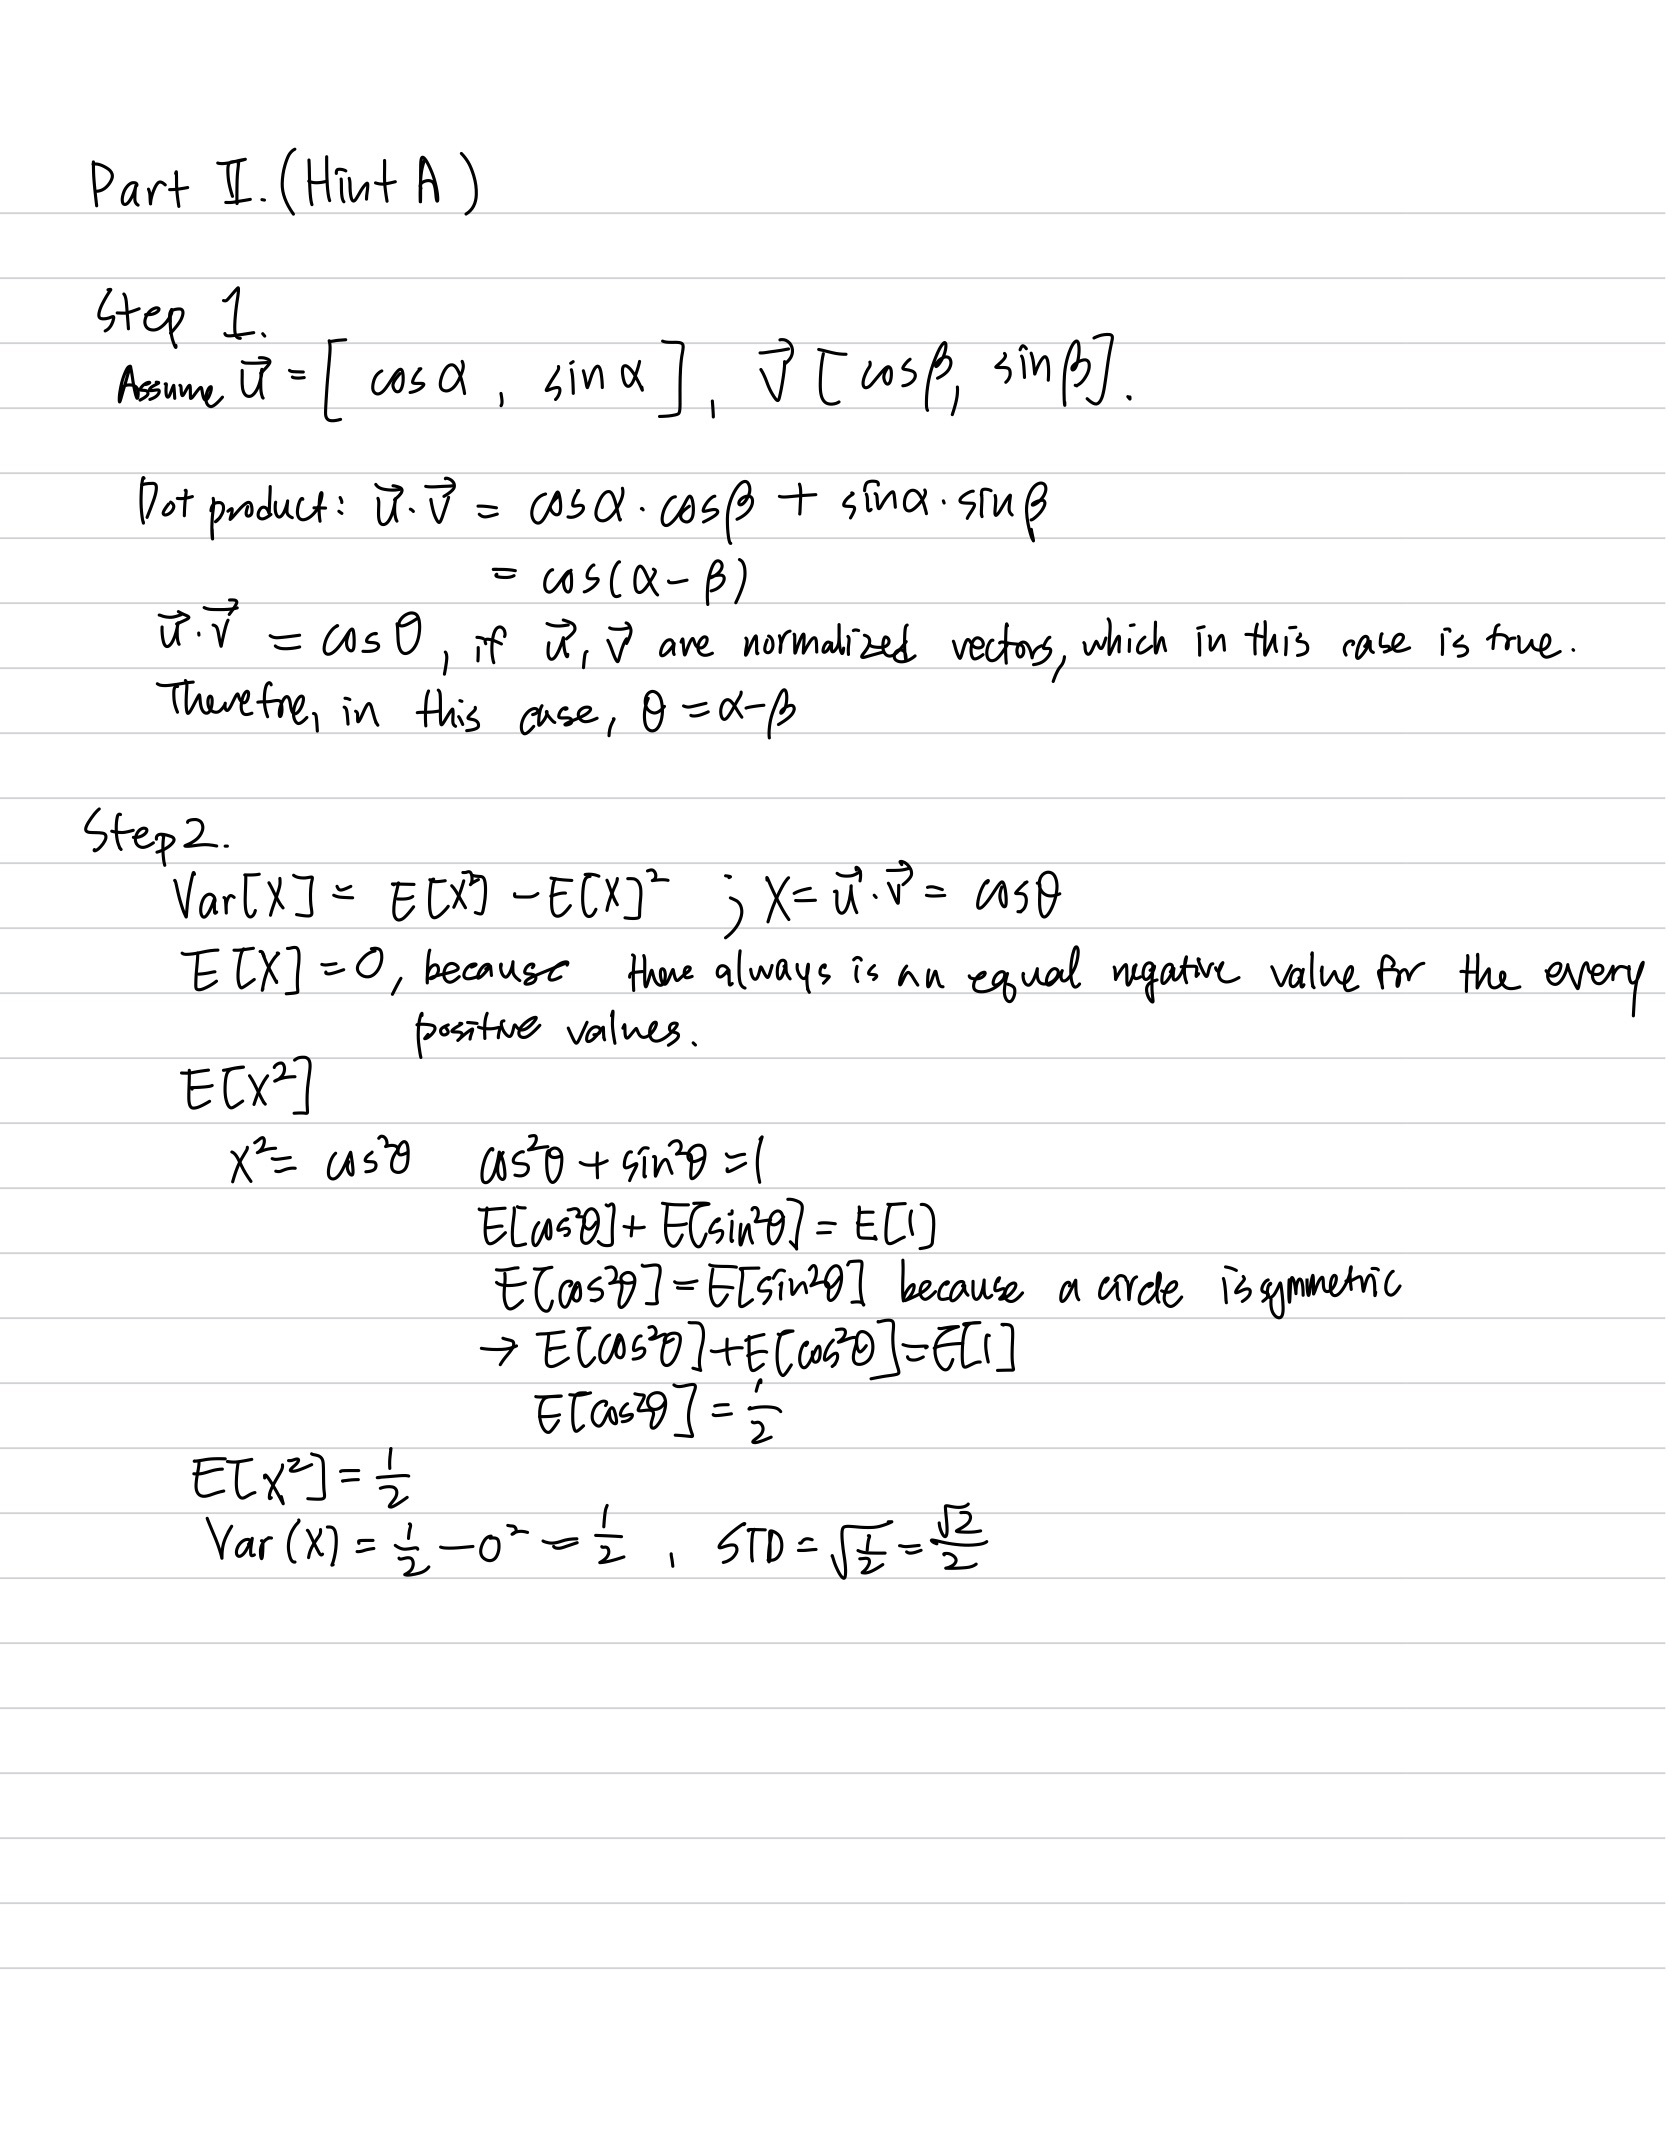




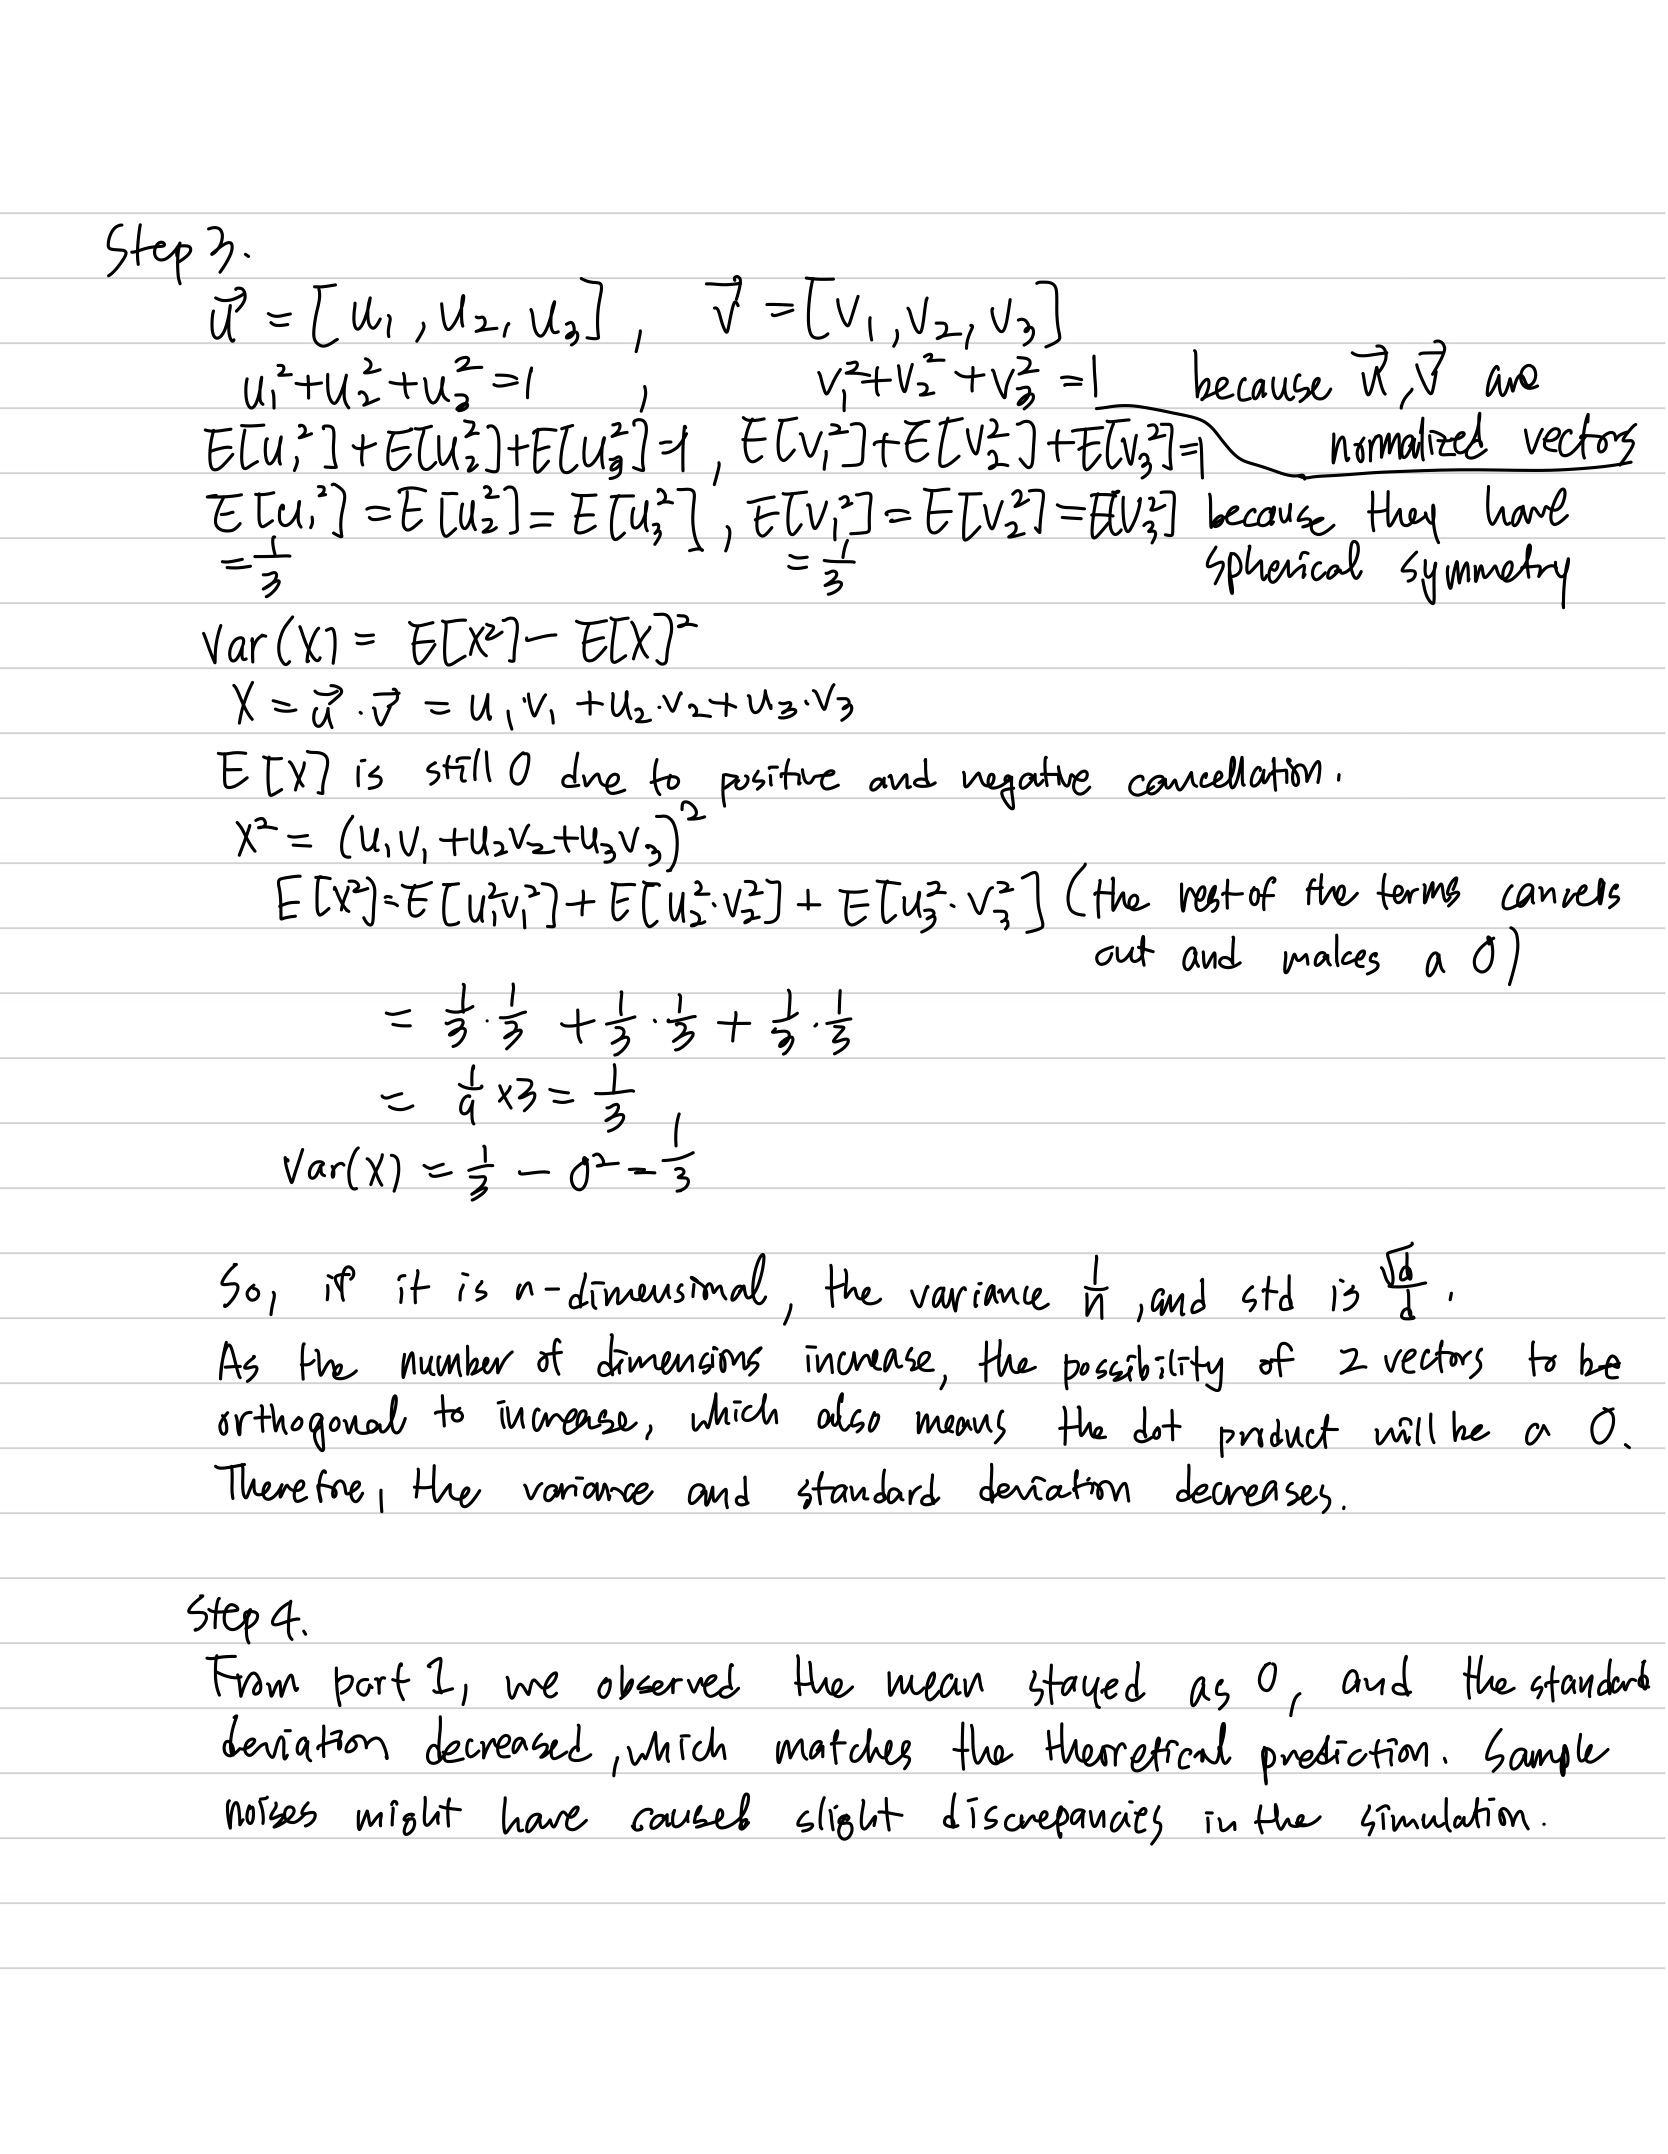

### Part 4

In [18]:
def generate_xy():
  x = np.random.rand(1)*2 - 1
  y = np.random.rand(1)*2 - 1
  return x, y

In [19]:
def check_inside(x, y):
  if np.sqrt(x**2 + y**2) > 1: # outside
    return 0
  else: # inside
    return 1

In [20]:
def pi_estimate(n):
  inside_sum = 0
  for i in range(n):
    x, y = generate_xy()
    inside = check_inside(x, y)
    inside_sum += inside

  # n/inside_sum ~= 4/pi
  # inside_sum/n ~= pi/4
  # 4*inside_sum/n ~= pi
  pi_estimate = 4*inside_sum/n
  return pi_estimate

In [21]:
pi_estimate1 = pi_estimate(50000)
print(pi_estimate1)
pi_estimate2 = pi_estimate(500000)
print(pi_estimate2)
pi_estimate3 = pi_estimate(5000000)
print(pi_estimate3)

3.13752
3.140728
3.142728


**ANALYSIS**

The final pi estimate I earned with sample size = 5000000 is 3.142728.

As I increased the sample size, the pi estimate approached more to ~3.14, which is the actual pi value, bringing up the accuracy significantly.

The geometric method gives an estimate of pi because the ratio of the area of the circle and the area of the tangential square (a square that all four sides touch the inscribed circle). If the radius of the circle is r, then the area of the circle is r * r * pi. The area tangential square is 2r * 2r, so r * r * 4. Therefore, the ratio of them will be pi to 4. Since the random distribution of a point in the 2D space will guarantee the equal probability of each event to occur, the ratio of the counts of points inside the circle to the counts of points in the tangential square will also be pi : 4. So, the formula to get the pi estimate will be 4 * inside_sum / n ~= pi.



### Part 5

Number of Hours spent: ~6 hours